In [104]:
%load_ext autoreload
%autoreload 2
%reset -f

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
from pathlib import Path
import os
from os.path import join
import sys
import sqlite3
# Find KPIHub root (directory containing lib/tables), then import lib.* as a package.
_here = Path.cwd().resolve()
_root = next((p for p in [_here, *list(_here.parents)[:12]] if (p / "lib" / "tables").is_dir()), None)
if _root is None:
    raise FileNotFoundError(
        f"Could not find KPIHub root (folder containing lib/tables). cwd={Path.cwd()!r}"
    )
sys.path.insert(0, str(_root))
os.chdir(_root)

from locallib.picarrodb import *
from locallib.slack import *
from locallib.etl import Loggers
from locallib.pandas import *
from locallib.box import *

from lib.tables.IngesterTables import *
from lib.handlers.CustomerHandler import *
from lib.config import *
from lib.KPIHubConnection import *
from lib.query.bank import *

from datetime import date
from datetime import timedelta

In [ ]:
customer_name = 'Toscana Energia'
file_name = f"{customer_name}_Yearly_Analysis.xlsx"

In [107]:
# FIXED: Proper parentheses, correct SQL, execute call outside Query call, and fetch result
query_string = f"""
    SELECT * FROM KPI_OutputExcelLocation 
    WHERE CustomerId = (
        SELECT CustomerId FROM KPI_Customer WHERE name = '{customer_name}'
    )
"""
result = Query(query=query_string).execute(KPIHub_Conn)
if result.empty:
    raise ValueError(f"No output Excel location found for customer: {customer_name}")
box_folder_id = result['BoxFolderId'].values[0]

In [108]:
#Get the columns of the view and get the KPI definitions
cols = Query("PRAGMA table_info('Yearly_KPI')").execute(KPIHub_Conn)
# Remove 'customerUtiliyation' and 'StandarTuiliyation' from cols DataFrame if present
cols = cols[~cols['name'].isin(['CustomerUtilization', 'StarndardUtilization','DaysCount','SurveysCarDay','PeakAboveSATCount','CumulativeAssetCoveredLengthKm','TargetDurationHours','PeriodValue'])]
cols.db.set_query("SELECT * FROM KPI_Definition WHERE name IN (SELECT name from temp_KPI)")
kpi_col = cols.db.execute(KPIHub_Conn, source_col = 'name', temp_table_name = 'temp_KPI')
output_dict = {kpi_col['Name']: [kpi_col['Unit'], kpi_col['Description'], kpi_col['Formula']] for _, kpi_col in kpi_col.iterrows()}

In [109]:
kpi_data = Query(f"SELECT {', '.join(cols['name'])} FROM Yearly_KPI WHERE CustomerName = '{customer_name}'").execute(KPIHub_Conn)
years= Query(f"SELECT DISTINCT Year FROM Yearly_KPI WHERE CustomerName = '{customer_name}'").execute(KPIHub_Conn)

In [110]:
# Select all rows where Year is 2025
kpi_2025 = kpi_data[kpi_data['Year'] == 2025].copy()
kpi_2025.set_index('BoundaryRegion', inplace=True)
kpi_2025.drop(columns=['CustomerName','Year'], inplace=True)
kpi_2026 = kpi_data[kpi_data['Year'] == 2026].copy()
kpi_2026.set_index('BoundaryRegion', inplace=True)
kpi_2026.drop(columns=['CustomerName','Year'], inplace=True)
kpi_diff = kpi_2026 - kpi_2025
kpi_pct_change = 100*((kpi_2026 / kpi_2025) - 1)
kpi_pct_change = kpi_pct_change.round(2)
kpi_diff.round(2)


,ReportAssetLengthKm,AssetCoveredLengthKm,DistributionPipeKm,DistributionPipeCoveredKm,ServicePipeKm,ServicePipeCoveredKm,ReportCount,FOVMain,SurveyDurationHours,TotalSurveyors,...,B1Density,Bm1Density,Bm2Density,B0Share,B1Share,Bm1Share,Bm2Share,NGShare,PGShare,Not_NGShare
BoundaryRegion,,,,,,,,,,,,,,,,,,,,,
None,-3265.98,-3186.69,-3265.98,-3186.69,0.0,0.0,-63.0,-0.22,-1003.29,19.0,...,0.00,0.03,0.03,-1.59,0.00,-0.03,1.62,-1.27,1.86,-0.59
Abruzzo,-128.35,-102.93,-128.35,-102.93,0.0,0.0,-3.0,0.86,-80.41,-2.0,...,0.00,0.01,0.03,-2.10,0.02,-0.45,2.53,4.96,-6.45,1.49
Calabria,-180.05,-180.61,-180.05,-180.61,0.0,0.0,-5.0,-0.29,-107.75,-1.0,...,0.01,0.02,0.02,-3.28,0.58,-0.52,3.22,0.20,3.06,-3.26
Campania,-83.89,-86.43,-83.89,-86.43,0.0,0.0,-6.0,-0.19,-135.66,-2.0,...,0.00,-0.17,0.00,-1.12,-0.13,-1.10,2.35,5.81,-7.73,1.92
Centro Italia,-89.66,-126.46,-89.66,-126.46,0.0,0.0,-2.0,-0.97,-81.92,-2.0,...,0.00,-0.04,-0.03,-0.39,-0.15,1.46,-0.92,1.30,0.18,-1.48
Lazio Sud,-94.29,-74.95,-94.29,-74.95,0.0,0.0,-3.0,0.41,75.34,0.0,...,0.01,0.12,0.04,-1.35,0.19,0.63,0.54,0.00,1.73,-1.74
Liguria,-293.20,-253.87,-293.20,-253.87,0.0,0.0,-6.0,0.51,-134.15,0.0,...,0.00,0.06,0.00,1.43,-0.01,-0.07,-1.36,-9.97,12.26,-2.29
Lombardia Nord-Est,-99.48,-93.94,-99.48,-93.94,0.0,0.0,-1.0,-0.06,-58.13,0.0,...,0.00,0.08,0.02,2.36,0.02,-1.94,-0.44,5.37,-1.06,-4.31
Lombardia Nord-Ovest,0.18,16.33,0.18,16.33,0.0,0.0,0.0,1.66,31.48,4.0,...,0.00,0.11,0.06,-3.49,-0.04,1.24,2.28,-7.46,5.17,2.29


In [111]:
with pd.ExcelWriter(file_name) as writer:
    for _, region_row in years.iterrows():
        year = region_row['Year']
        # Select the export_df according to region (handle null safely)

        export_df = kpi_data[kpi_data['Year'] == year].copy()
        sheet_name = f"KPI {year} Yearly"

        # Fill PeakAboveSATCount with 0, but only if column exists
        if 'PeakAboveSATCount' in export_df.columns:
            export_df['PeakAboveSATCount'] = export_df['PeakAboveSATCount'].fillna(0)

        # Process the column name
        units = []
        for col in export_df.columns:
            if col in kpi_col['Name'].values:
                units.append(kpi_col.loc[kpi_col['Name'] == col, 'Unit'].values[0])
            else:
                units.append("")

        # Write the filtered DataFrame to the first sheet
        # Write columns and units as first two rows, then export the rest of the DataFrame
        rows = export_df.values.tolist()
        full_rows = [export_df.columns.tolist(), units] + rows
        temp_df = pd.DataFrame(full_rows)

        temp_df.to_excel(writer, sheet_name=sheet_name, index=False, header=False)

        # Post-process the sheet for bold and center alignment of the first two columns
        worksheet = writer.sheets[sheet_name]
        # Create bold and center formats
        bold_center = writer.book.add_format({'bold': True, 'align': 'center'})
        center = writer.book.add_format({'align': 'center'})

        # The first two rows (headers and units): apply bold and center format to *all* columns, not just columns 0 and 1
        for row_idx in range(2):
            for col_idx in range(len(full_rows[row_idx])):
                worksheet.write(row_idx, col_idx, full_rows[row_idx][col_idx], bold_center)  # overwrite with bold+center

        # All other rows: just center the first two columns
        for i, row in enumerate(rows, start=2):
            for col in range(2):
                worksheet.write(i, col, row[col], center)
        # Add a colored line (cell border) at the bottom of all cells in the second row (units row)
        bottom_border_format = writer.book.add_format({'bottom': 1, 'bottom_color': '#000000', 'align': 'center', 'bold': True})
        for col_idx in range(len(full_rows[1])):
            worksheet.write(1, col_idx, full_rows[1][col_idx], bottom_border_format)

        # Auto-adjust column widths based on the maximum length in each column
        for idx, col in enumerate(export_df.columns):
            # Find the max length of any value in this column (including header and units)
            max_len = max(
                [len(str(col)), len(str(units[idx]))] +
                [len(str(row[idx])) for row in rows]
            )
            # Set the width (add some padding)
            worksheet.set_column(idx, idx, max_len + 2)

    

    # Write the key and its list of [Unit, Description, Formula Used] as columns in the second sheet
    desc_rows = []
    for key, value in output_dict.items():
        if isinstance(value, list) and len(value) == 3:
            # Value is a list: [Unit, Description, Formula Used]
            row = [key] + value
        else:
            # Fallback in case the dictionary isn't formatted as expected
            row = [key, "", "", ""] 
        desc_rows.append(row)
    columns = ["Key", "Unit", "Description", "Formula Used"]
    desc_df = pd.DataFrame(desc_rows, columns=columns)
    desc_df.to_excel(writer, sheet_name="KPI Descriptions", index=False)
    
    # Write KPI differences to Excel and auto-adjust column widths for this sheet
    

    kpi_diff.to_excel(writer, sheet_name="KPI Diff 26-25", index=True)
    worksheet_diff = writer.sheets["KPI Diff 26-25"]
    for idx, col in enumerate(kpi_diff.reset_index().columns):
        # Include both the column name and the maximum data width for auto-sizing
        max_len = max(
            [len(str(col))] +
            [len(str(val)) for val in kpi_diff.reset_index()[col]]
        )
        worksheet_diff.set_column(idx, idx, max_len + 2)

    # Fill NaN/inf/-inf with a string or value Excel can accept, e.g., empty string or some placeholder
    kpi_pct_clean = kpi_pct_change.replace([float('inf'), float('-inf')], pd.NA)
    kpi_pct_clean = kpi_pct_clean.fillna("")  # or use np.nan_to_num() if appropriate and if imported

    kpi_pct_clean.to_excel(writer, sheet_name="KPI Percentage Changes", index=True)
    worksheet_pct_change = writer.sheets["KPI Percentage Changes"]

    # Define a red text format for positives
    red_text_format = writer.book.add_format({'font_color': 'red'})

    # Write data and auto-fit columns
    kpi_pct_reset = kpi_pct_clean.reset_index()
    for row_idx in range(len(kpi_pct_reset)):
        for col_idx, col in enumerate(kpi_pct_reset.columns):
            cell_value = kpi_pct_reset.iloc[row_idx, col_idx]
            # Try to color positive values in red (skip the first column if it's index/text)
            if col_idx > 0:
                # Only try to cast to float if the cell is not empty
                try:
                    # Replace empty string with 0 for numeric comparison, or just skip coloring for empty/non-numeric
                    if pd.notnull(cell_value) and cell_value != "":
                        val = float(cell_value)
                        if val > 0:
                            worksheet_pct_change.write(row_idx + 1, col_idx, cell_value, red_text_format)
                        else:
                            worksheet_pct_change.write(row_idx + 1, col_idx, cell_value)
                    else:
                        worksheet_pct_change.write(row_idx + 1, col_idx, cell_value)
                except Exception:
                    worksheet_pct_change.write(row_idx + 1, col_idx, cell_value)
            else:
                worksheet_pct_change.write(row_idx + 1, col_idx, cell_value)

    # Write the header row with default formatting
    for col_idx, col in enumerate(kpi_pct_reset.columns):
        worksheet_pct_change.write(0, col_idx, col)

    # Set auto column widths
    for idx, col in enumerate(kpi_pct_reset.columns):
        max_len = max(
            [len(str(col))] +
            [len(str(val)) for val in kpi_pct_reset[col]]
        )
        worksheet_pct_change.set_column(idx, idx, max_len + 2)

In [112]:
box_obj = BoxFile(local_path = file_name, box_folder_id = box_folder_id)
box_obj.upload()
box_obj.delete()

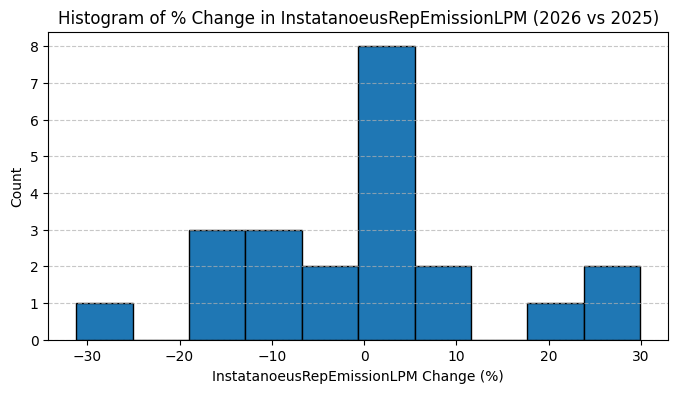

In [113]:
# Select all rows where Year is 2025
kpi_2025 = kpi_data[kpi_data['Year'] == 2025].copy()
kpi_2025.set_index('BoundaryRegion', inplace=True)
kpi_2025.drop(columns=['CustomerName','Year'], inplace=True)
kpi_2026 = kpi_data[kpi_data['Year'] == 2026].copy()
kpi_2026.set_index('BoundaryRegion', inplace=True)
kpi_2026.drop(columns=['CustomerName','Year'], inplace=True)
kpi_diff = 100*((kpi_2026 / kpi_2025) - 1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(kpi_diff['NightDrivenLength'].dropna(), bins=10, edgecolor='black')
plt.xlabel('InstatanoeusRepEmissionLPM Change (%)')
plt.ylabel('Count')
plt.title('Histogram of % Change in InstatanoeusRepEmissionLPM (2026 vs 2025)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [114]:
kpi_diff['NightDrivenLength']

BoundaryRegion
None                       -1.765425
Abruzzo                     0.303784
Calabria                   18.327464
Campania                    0.028403
Centro Italia             -11.188490
Lazio Sud                  11.056294
Liguria                     3.531597
Lombardia Nord-Est          2.130083
Lombardia Nord-Ovest       29.899409
Lombardia Sud              26.539242
Napoli                    -17.741819
Piemonte Est                8.823755
Piemonte Ovest            -14.125732
Puglia Nord - Molise       -1.011378
Puglia Sud - Basilicata   -10.057489
Roma-Nord                  -9.899483
Roma-Sud                    0.830779
Sicilia Est                 0.255942
Sicilia Ovest             -31.190538
Torino                      2.478241
Veneto Nord - Friuli        2.501315
Veneto Sud                -16.004514
Name: NightDrivenLength, dtype: float64

In [115]:
kpi_diff.columns.shape

(56,)